# SimonResearch · Model and Holding Strategy

This experiment keeps the **same stock universe, daily price scope, and nine features as `Data.ipynb`** and the frozen model selected using 2023 validation. It evaluates Simon's $1 million long/short holding strategy on 2024–2025, separately from the archived daily intraday strategy.

The current-constituent universe remains exploratory. Our ultimate goal is a published paper; that later stage will revisit historical membership, data scope, novelty and untouched confirmation data.

**Run every cell in order.** Results are loaded from recorded artifacts, not entered manually.

## 1. Use the research environment

From the **SimonResearch checkout**, install the model dependencies and launch Jupyter with its interpreter:

```bash
python3.12 -m venv .venv
.venv/bin/python -m pip install -r requirements-showcase.txt notebook
.venv/bin/python -m jupyter notebook notebooks/SimonResearch_Showcase.ipynb
```

Select the kernel from this environment. The experiment can also run directly with `.venv/bin/python scripts/run_showcase.py`. The first run may download the notebook's price snapshot and train the models; subsequent runs reuse the saved snapshot and artifacts. `--refresh-data` intentionally changes the snapshot, and `--retrain` reruns fitting.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

# Notebook works when opened from the repo root or the notebooks directory.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "scripts" / "run_showcase.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from the SimonResearch checkout.")
REPORT_DIR = ROOT / "reports" / "showcase"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Repository:", ROOT)
print("Python:", sys.executable)


Repository: /Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch
Python: /Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/.venv/bin/python


## 2. Build or reuse the recorded experiment

The run keeps stock observations together by date: **train 2016–2022, validation 2023, test 2024–2025**, with boundary-crossing labels purged. Model settings and ensemble weights are selected using validation observations. The test window measures this particular demonstration; if we repeatedly develop on it, it becomes exploratory data and cannot serve as the paper's untouched confirmation set.

Set `RETRAIN = True` only when you deliberately want a new experiment. Changes to `ITERATIONS` or `THREADS` affect fitting only when retraining; with `RETRAIN = False`, completed artifacts are reused. Leave `REFRESH_DATA = False` to preserve the saved price snapshot.

In [2]:
RETRAIN = False
REFRESH_DATA = False
ITERATIONS = 500
THREADS = 4

command = [sys.executable, str(ROOT / "scripts" / "run_showcase.py"),
           "--iterations", str(ITERATIONS), "--threads", str(THREADS)]
if RETRAIN:
    command.append("--retrain")
if REFRESH_DATA:
    command.append("--refresh-data")
subprocess.run(command, cwd=ROOT, check=True)


Reusing the completed frozen experiment. Use --rebacktest for new execution or --retrain for an explicit new fit.

Report: /Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/reports/showcase/index.html
Selected on validation: {'xgb_ranker': 1.0}
Test rank IC: 0.0114; gross return: 8.16%; net return: 8.16%; net Sharpe: 0.65
Initial capital: $1,000,000; ending net equity: $1,081,595.
Resolved sessions: 501/501; costs: 0 bps per side.


CompletedProcess(args=['/Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/.venv/bin/python', '/Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/scripts/run_showcase.py', '--iterations', '500', '--threads', '4'], returncode=0)

## 3. Inspect provenance and model selection

These values come from saved experiment artifacts. Changing the data snapshot or fitting settings produces a different recorded experiment.

In [3]:
import pandas as pd
from IPython.display import display, HTML, SVG

summary = json.loads((REPORT_DIR / "summary.json").read_text())
leaderboard = pd.read_csv(REPORT_DIR / "leaderboard.csv")
daily = pd.read_csv(REPORT_DIR / "daily.csv")
top_predictions = pd.read_csv(REPORT_DIR / "top_predictions.csv")
feature_importance = pd.read_csv(REPORT_DIR / "feature_importance.csv")

display(pd.DataFrame(summary["splits"]).T)
display(pd.Series(summary["dataset"], name="Dataset provenance"))
print("Experiment:", summary["experiment_id"])
print("Frozen selected forecast weights:")
display(pd.Series(summary.get("training", {}).get("selected_weights", {}), dtype="float64"))


,start,end,rows,labeled_rows,dates
train,2016-03-31,2022-12-29,809852,809834,1701
validation,2023-01-03,2023-12-28,122564,122564,249
test,2024-01-02,2025-12-31,249614,249114,502


snapshot_created_at                         2026-10-06T23:58:09.384708-05:00
source                     https://en.wikipedia.org/wiki/List_of_S%26P_50...
price_source                                  Yahoo Finance through yfinance
requested_start                                                   2016-01-01
requested_end_exclusive                                           2026-01-01
start                                                             2016-01-04
end                                                               2025-12-31
rows                                                                 1183015
quote_rows                                                           1264542
tickers                                                                  499
requested_tickers                                                        503
unavailable_tickers                                       [FDXF, HONA, PSKY]
features                   [ret_1d, mom_5d, mom_20d, mom_60d, vol_5d, vol...

Experiment: f9068e97eaac
Frozen selected forecast weights:


xgb_ranker    1.0
dtype: float64

## 4. The $1 million long/short holding strategy

The test starts with **$1,000,000 on January 2, 2024**; the first scheduled fills occur January 3. The frozen XGBoost Ranker scores each closing cross-section. Top 20 stocks receive long additions, and bottom 20 receive short additions. Existing longs remain while in the top 100; shorts remain while in the bottom 100. A closing threshold breach schedules an exit for the **next trading session**, so the decision never uses a closing rank for a same-day fill.

At each signal-date close, all available free cash is budgeted **50% to long entry capital and 50% to short entry collateral**, spread across that side's 20 entry ranks. Additions can increase existing positions; retained names outside the current top/bottom 20 stay held, so holdings may exceed 20 per side. Short-sale proceeds and 100% entry collateral are segregated and cannot fund further entries. Filled exits release cash that becomes available at the fill-day close, funding entries on the following session.

Fills use a next-session **adjusted OHLC4 proxy**, `(Open + High + Low + Close) / 4 × Adj Close / Close` for consistent synthetic adjusted-price/unit accounting. This is not a guaranteed executable quote and does not claim actual cash-dividend accounting. Commission and borrowing costs are read from the recorded evaluation below. When both settings are zero, the report shows one NAV curve and results exclude these costs. Archived or future nonzero-cost runs retain the before/after comparison.

In [4]:
from src.reporting.showcase import costs_are_zero

evaluation = summary.get("evaluation", {})
cost_free = costs_are_zero(evaluation)
result_fields = ["strategy_name", "initial_capital", "final_net_equity",
                 "net_cumulative_return", "annualized_sharpe", "max_drawdown",
                 "cost_bps", "annual_borrow_bps", "trading_dates", "aggregate_resolved_dates"]
if not cost_free:
    result_fields[2:2] = ["final_gross_equity", "gross_cumulative_return"]
labels = {
    "initial_capital": "Initial capital",
    "final_net_equity": "Ending NAV" if cost_free else "Ending NAV after costs",
    "final_gross_equity": "Ending NAV before costs",
    "net_cumulative_return": "Return" if cost_free else "Net return",
    "gross_cumulative_return": "Gross return",
    "annualized_sharpe": "Sharpe" if cost_free else "Net Sharpe",
    "max_drawdown": "Max drawdown",
    "cost_bps": "Commission (bps per side)",
    "annual_borrow_bps": "Borrow fee (bps per year)",
}
display(pd.Series({labels.get(key, key): evaluation[key] for key in result_fields if key in evaluation},
                  name="Recorded strategy results — costs excluded" if cost_free else "Recorded strategy results"))
nav_columns = [key for key in ["Date", "net_nav"] if key in daily] if cost_free else [
    key for key in ["Date", "gross_nav", "net_nav"] if key in daily]
if {"gross_nav", "net_nav"}.issubset(daily.columns):
    endpoints = daily[nav_columns].iloc[[0, -1]]
    display(endpoints.rename(columns={"net_nav": "NAV"}) if cost_free else endpoints)
else:
    print("These artifacts use the archived intraday strategy; rerun the updated strategy command.")


strategy_name                rank_hold_long_short
Initial capital                         1000000.0
Ending NAV                         1081594.783955
Return                                   0.081595
Sharpe                                   0.649944
Max drawdown                            -0.069838
Commission (bps per side)                     0.0
Borrow fee (bps per year)                     0.0
trading_dates                                 501
aggregate_resolved_dates                      501
Name: Recorded strategy results — costs excluded, dtype: object

,Date,NAV
0,2024-01-02,1.000000e+06
501,2025-12-31,1.081595e+06


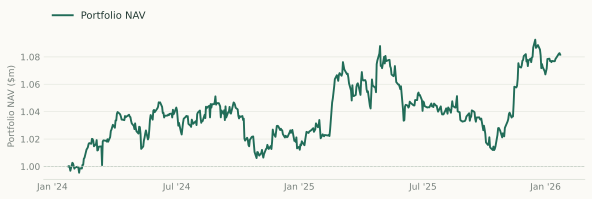

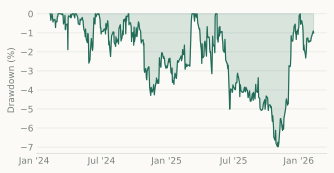

In [5]:
def show_figure(name):
    path = REPORT_DIR / "figures" / f"{name}.svg"
    if path.exists():
        display(SVG(filename=str(path)))
    else:
        print(f"No exported {name} figure for this experiment.")

show_figure("strategy_equity")
show_figure("drawdown_net")


## 5. Look inside the model

The importance chart describes the fitted models; it does not identify a causal economic mechanism. The exported prediction snapshot is a historical demonstration, not a live trade instruction. Predicted returns are decimals, while the selected model's rank score measures relative cross-sectional ordering.

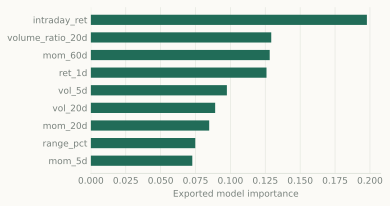

,feature,importance
0,intraday_ret,0.197821
1,volume_ratio_20d,0.129270
2,mom_60d,0.128166
3,ret_1d,0.125877
4,vol_5d,0.097482
5,vol_20d,0.089076
6,mom_20d,0.084802
7,range_pct,0.074813
8,mom_5d,0.072694


,Date,Ticker,rank,score,prediction,disagreement
0,2025-12-31,JBHT,1,0.997996,0.001177,0.403124
1,2025-12-31,LITE,2,0.993988,0.001176,0.959667
2,2025-12-31,GM,3,0.989980,0.001174,0.272837
3,2025-12-31,COHR,4,0.985972,0.001173,0.242650
4,2025-12-31,CAH,5,0.981964,0.001172,0.476368
5,2025-12-31,ISRG,6,0.977956,0.001171,0.112344
6,2025-12-31,SWKS,7,0.973948,0.001170,0.034763
7,2025-12-31,PYPL,8,0.969940,0.001168,0.026148
8,2025-12-31,CTSH,9,0.965932,0.001167,0.296329
9,2025-12-31,SMCI,10,0.961924,0.001166,0.017471


In [6]:
show_figure("feature_importance")
display(feature_importance)
if "Date" in top_predictions:
    parsed_dates = pd.to_datetime(top_predictions["Date"], errors="coerce")
    snapshot = top_predictions.loc[parsed_dates.eq(parsed_dates.max())]
else:
    snapshot = top_predictions
if "rank" in snapshot:
    snapshot = snapshot.sort_values("rank")
display(snapshot.head(10))


## 6. Open the showcase and preserve the research trail

`reports/showcase/index.html` is a self-contained dashboard with no network dependencies. Its SVG and PNG figures can be reused in a club presentation. `summary.json` retains the snapshot hash, dates, model selection metadata and limitations; the CSVs retain the actual observations behind the display.

Our eventual paper plan is recorded in `docs/research-roadmap.md`. After this demo, we can investigate a specific model behavior, reproduce the relevant literature, expand the data appropriately, and reserve a new confirmation evaluation.

In [7]:
dashboard = REPORT_DIR / "index.html"
print("Dashboard:", dashboard)
display(HTML(dashboard.read_text()))
print("Recorded limitations:")
for item in summary.get("limitations", []):
    print("•", item)


Dashboard: /Users/simonz666/Desktop/UIUC/Financial Engineering Club/financial-engineering-club-fall26-SimonResearch/reports/showcase/index.html


Recorded limitations:
• The Wikipedia universe is current at download time; historical results have survivorship and future-membership selection bias.
• The Yahoo Finance snapshot is not point-in-time institutional data; adjusted history can be revised.
• OHLC4 is a hypothetical full-day execution proxy, not VWAP or a guaranteed attainable fill. Orders use only prior-session information.
• Adjusted total-return units approximate corporate actions; actual dividend cash timing, short dividend obligations and verified split-share inventories are not modeled.
• Short-sale proceeds and equal entry collateral are reserved; real maintenance margin, stock-loan availability, recalls and borrow fees are not modeled.
• The fixed next-day forecast target and a multi-day ranking exit strategy have different holding horizons.
• Configured transaction and borrow fees are simplified; a zero-fee run excludes trading costs. Market impact, volume participation limits and spread variation are unmodeled. E